### Data sandbox 

*Puisqu'on part d'un dataset relationel, le but ici est de trouver une manière simple de merger la data provenant des 4 tables.*

In [1]:
import dask.dataframe as dd

SIMULATED_FOLDER = "../ressources/data/0_archive/Insurance_Churn_ParticipantsData/simulated/"

In [2]:
df_adress = dd.read_csv(SIMULATED_FOLDER + 'address.csv')
df_customer = dd.read_csv(SIMULATED_FOLDER + 'customer.csv')
df_demographic = dd.read_csv(SIMULATED_FOLDER + 'demographic.csv')
df_termination = dd.read_csv(SIMULATED_FOLDER + 'termination.csv')

In [4]:
raw_variables = {
    'adress_table': list(df_adress.columns),
    'customer_table': list(df_customer.columns),
    'demographic_table': list(df_demographic.columns),
    'termination_table': list(df_termination.columns)
}

import pickle

with open('../ressources/data/1_raw/raw_variables_and_tables.pkl', 'wb') as f:
    pickle.dump(raw_variables, f)

In [ ]:
df_full = df_customer.copy()

df_full = df_full.merge(df_termination, left_on='INDIVIDUAL_ID', right_on='INDIVIDUAL_ID', how='left') # table faits

# simultanement
df_full = df_full.merge(df_demographic, left_on='INDIVIDUAL_ID', right_on='INDIVIDUAL_ID', how='left') # dim geographique
df_full = df_full.merge(df_adress, left_on='ADDRESS_ID', right_on='ADDRESS_ID', how='left') # dim adresse

df_full.head()

,INDIVIDUAL_ID,ADDRESS_ID,CURR_ANN_AMT,DAYS_TENURE,CUST_ORIG_DATE,AGE_IN_YEARS,DATE_OF_BIRTH,SOCIAL_SECURITY_NUMBER,ACCT_SUSPD_DATE,INCOME,...,HOME_MARKET_VALUE,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT,LATITUDE,LONGITUDE,STREET_ADDRESS,CITY,STATE,COUNTY
0,2.213000e+11,5.213000e+11,818.877997,1454.0,2018-12-09,44.474,1978-06-23,608-XX-7640,NaN,22500.0,...,50000 - 74999,1.0,1.0,1.0,32.578829,-96.305006,52966 Welch Crescent,Kaufman,TX,Kaufman
1,2.213001e+11,5.213001e+11,974.199182,1795.0,2018-01-02,72.559,1950-05-30,342-XX-6908,NaN,27500.0,...,50000 - 74999,1.0,0.0,0.0,32.732209,-97.000893,46887 Lawrence Green,Grand Prairie,TX,Dallas
2,2.213007e+11,5.213002e+11,967.375112,4818.0,2009-09-23,55.444,1967-07-07,240-XX-9224,NaN,42500.0,...,75000 - 99999,1.0,0.0,0.0,32.819777,-96.846938,787 Daniel Mews Suite 806,Dallas,TX,Dallas
3,2.213016e+11,5.213006e+11,992.409561,130.0,2022-07-25,53.558,1969-05-25,775-XX-6249,2021-12-22,125000.0,...,175000 - 199999,1.0,0.0,1.0,32.684065,-97.162180,9846 Shaw Manor Apt. 774,Arlington,TX,Tarrant
4,2.213016e+11,5.213006e+11,784.633494,5896.0,2006-10-11,50.220,1972-09-25,629-XX-7298,NaN,87500.0,...,225000 - 249999,1.0,1.0,1.0,32.751398,-97.376745,431 David Port Apt. 164,Fort Worth,TX,Tarrant


In [10]:
df_full.head().to_parquet('../ressources/data/1_raw/head_df_full.parquet', engine='pyarrow')

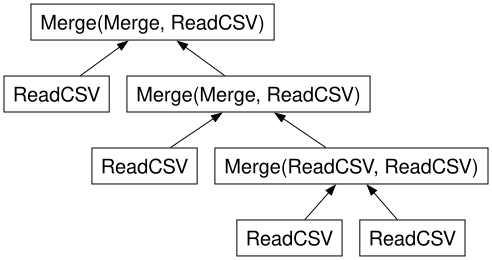

In [40]:
df_full.visualize()

In [14]:
name_function = lambda x: f"data-{x}.parquet"
df_full.to_parquet(f"{SIMULATED_FOLDER}/../train/", name_function=name_function, compression='gzip', write_index=False)  

In [11]:
import pandas as pd

df = [
    pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-0.parquet'),
    pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-1.parquet'),
    pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-2.parquet')
]

df = pd.concat(df, axis=0)
df.shape

(2280321, 23)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2280321 entries, 0 to 760068
Data columns (total 23 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   INDIVIDUAL_ID           float64
 1   ADDRESS_ID              float64
 2   CURR_ANN_AMT            float64
 3   DAYS_TENURE             float64
 4   CUST_ORIG_DATE          object 
 5   AGE_IN_YEARS            float64
 6   DATE_OF_BIRTH           object 
 7   SOCIAL_SECURITY_NUMBER  object 
 8   ACCT_SUSPD_DATE         object 
 9   INCOME                  float64
 10  HAS_CHILDREN            float64
 11  LENGTH_OF_RESIDENCE     float64
 12  MARITAL_STATUS          object 
 13  HOME_MARKET_VALUE       object 
 14  HOME_OWNER              float64
 15  COLLEGE_DEGREE          float64
 16  GOOD_CREDIT             float64
 17  LATITUDE                float64
 18  LONGITUDE               float64
 19  STREET_ADDRESS          object 
 20  CITY                    object 
 21  STATE                   object 
 22  

In [ ]:
df_full.shape

In [1]:
txt = "On est parti de 4 tables pour arriver à une seule table de 2 280 321 lignes et 22 colonnes. La table finale utilise 420MB de mémoire vive donc x5 pour la traiter avec pandas donc cette partie a été faite avec dask."

with open('../ressources/data/1_raw/summary.txt', 'w') as f:
    f.write(txt)